# Exercise: Data Visualization
- Tampilkan visualisasi yang sesuai
- Berikan insightnya

In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [39]:
df = pd.read_excel('sample_-_superstore.xls', sheet_name='Orders')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


### **No.1**

Tampilkan distribusi Sales

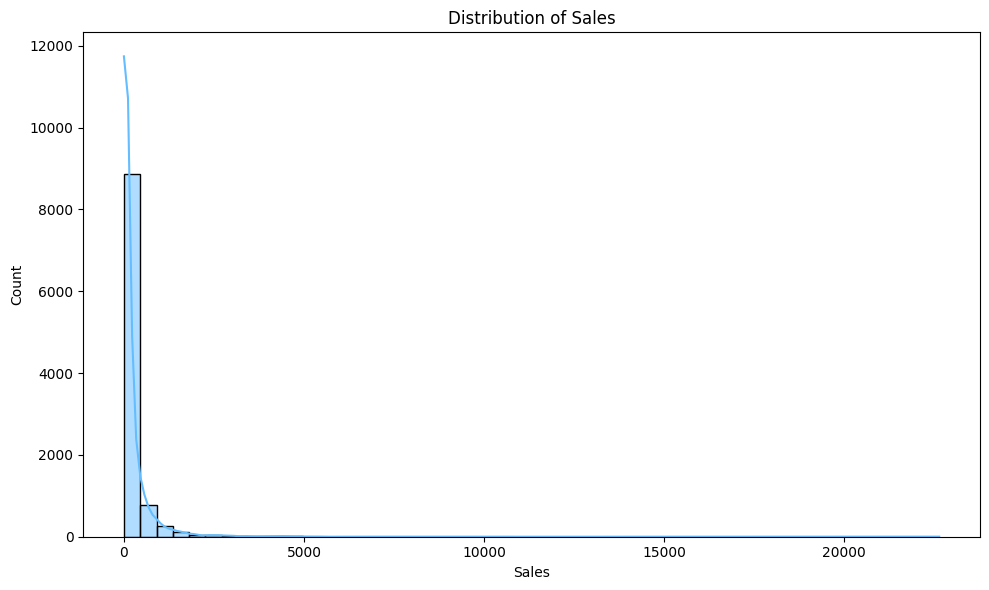

In [40]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Sales'], bins=50, kde=True, color='#63BDFF')
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### **No.2**

Apakah ada outliers di variable Sales? Di nilai berapa nilai Sales dianggap outliers?

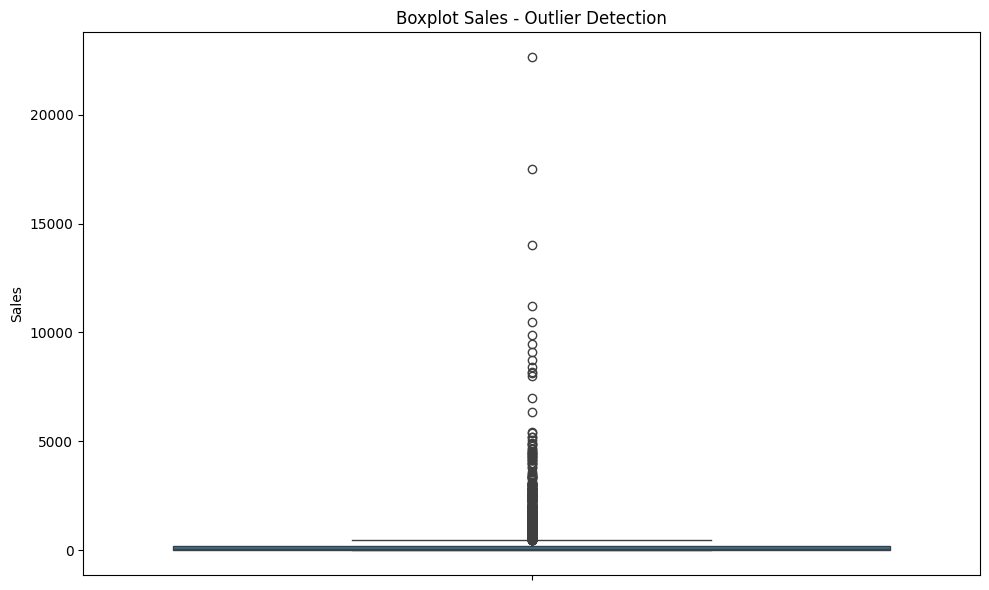

In [41]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[df['Sales'] > upper]
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Sales'])
plt.title('Boxplot Sales - Outlier Detection')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

### **No.3**

Tampilkan total profit tiap Category

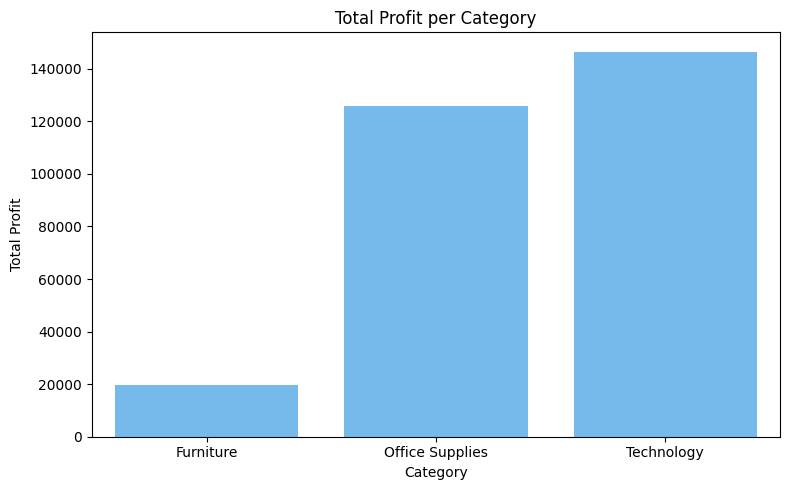

In [42]:
grouped = df.groupby('Category')['Profit'].sum().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=grouped, x='Category', y='Profit', color = '#63BDFF')
plt.title('Total Profit per Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.tight_layout()
plt.show()

### **No.4**

Tampilkan total profit tiap Segment yang dibagi lagi per Category

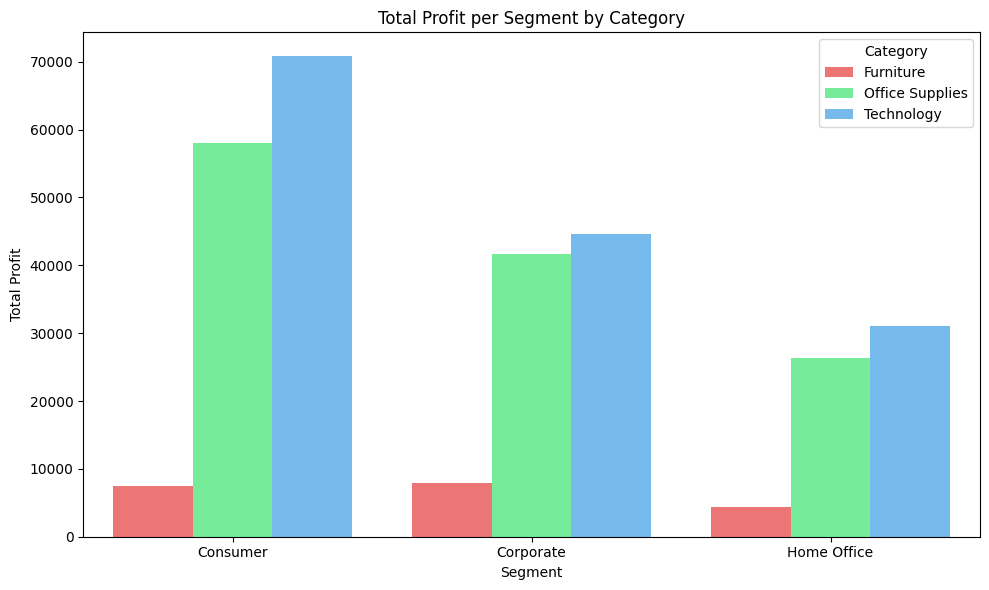

In [43]:
grouped = df.groupby(['Segment', 'Category'])['Profit'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=grouped, x='Segment', y='Profit', hue='Category', palette=['#FF6363', '#63FF94', '#63BDFF']) 
plt.title('Total Profit per Segment by Category')
plt.xlabel('Segment')
plt.ylabel('Total Profit')
plt.legend(title='Category')
plt.tight_layout()
plt.show()

### **No.5**

Apakah ada hubungan antara Discount dan Profit?

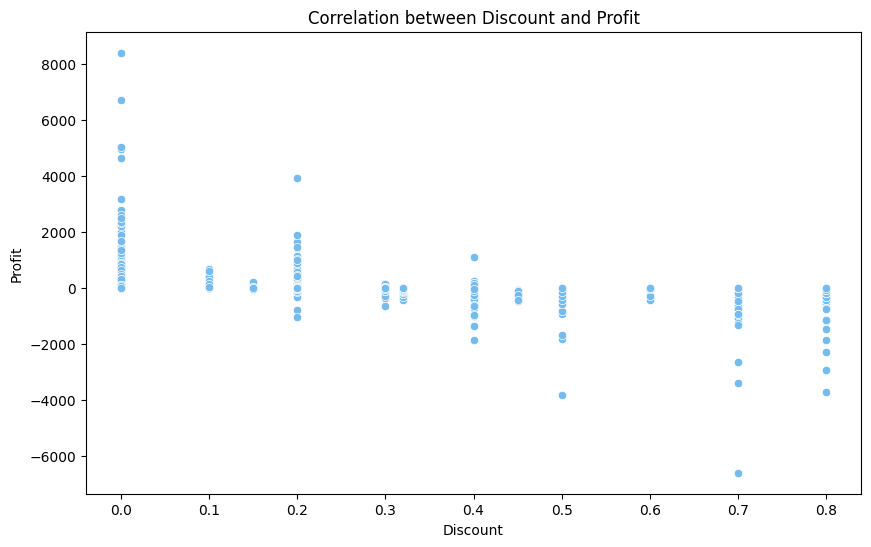

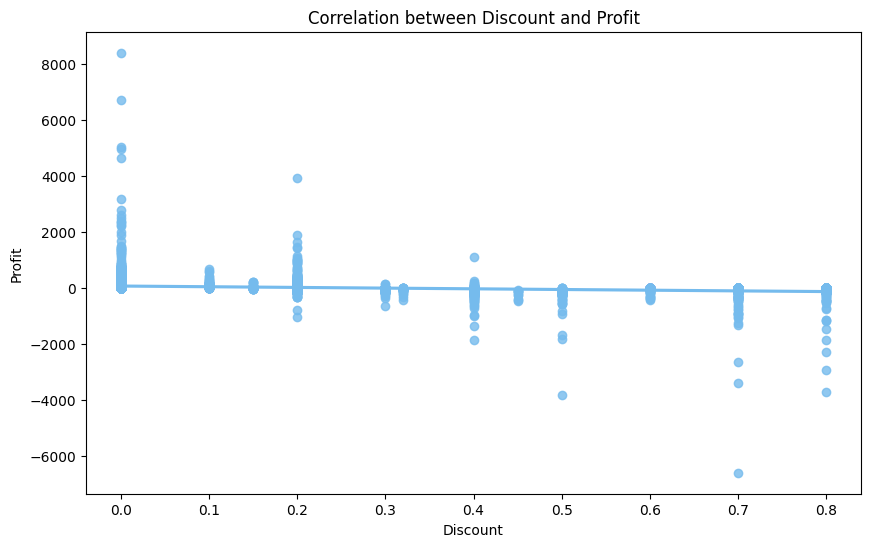

In [44]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', color = "#75BBED")
plt.title("Correlation between Discount and Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Discount', y='Profit', color = "#75BBED")
plt.title("Correlation between Discount and Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

There's a correlation between discount and profit.
From 0.0 to 0.2 we can see a steady decline but still hovering around the positive mark on profit.
However the higher the discount, the lower the profit drops eventually dropping into the negatives. Hence why based on our findings, it's a very risky endeavour when offering discounts beyond 20%.

### **No.6**

Tampilkan total profit tiap bulan dari 2023-2026

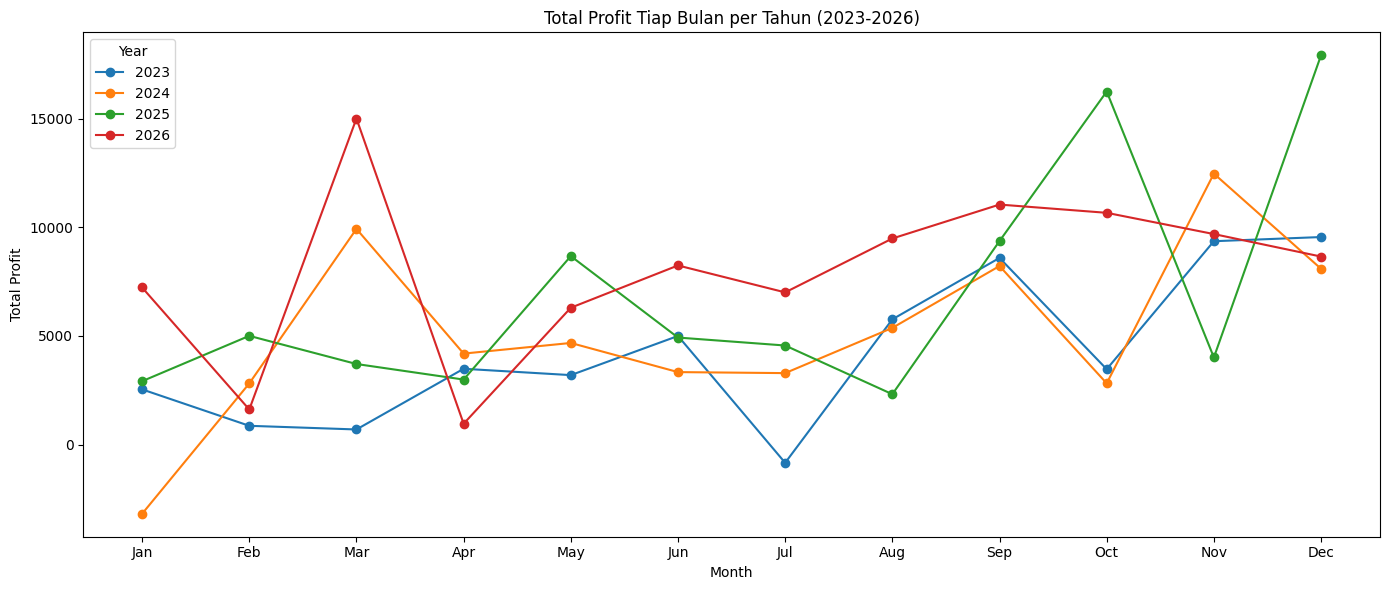

In [45]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

monthly_profit = df.groupby(['Year', 'Month'])['Profit'].sum().reset_index()

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(14, 6))
for year in sorted(monthly_profit['Year'].unique()):
    data = monthly_profit[monthly_profit['Year'] == year]
    plt.plot(data['Month'], data['Profit'], marker='o', label=str(year))

plt.title('Total Profit Tiap Bulan per Tahun (2023-2026)')
plt.xlabel('Month')
plt.ylabel('Total Profit')
plt.xticks(ticks=range(1, 13), labels=month_names)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

### **No.7**

Bandingkan trend profit pada tanggal 15 dan tanggal 28 dari tiap bulan

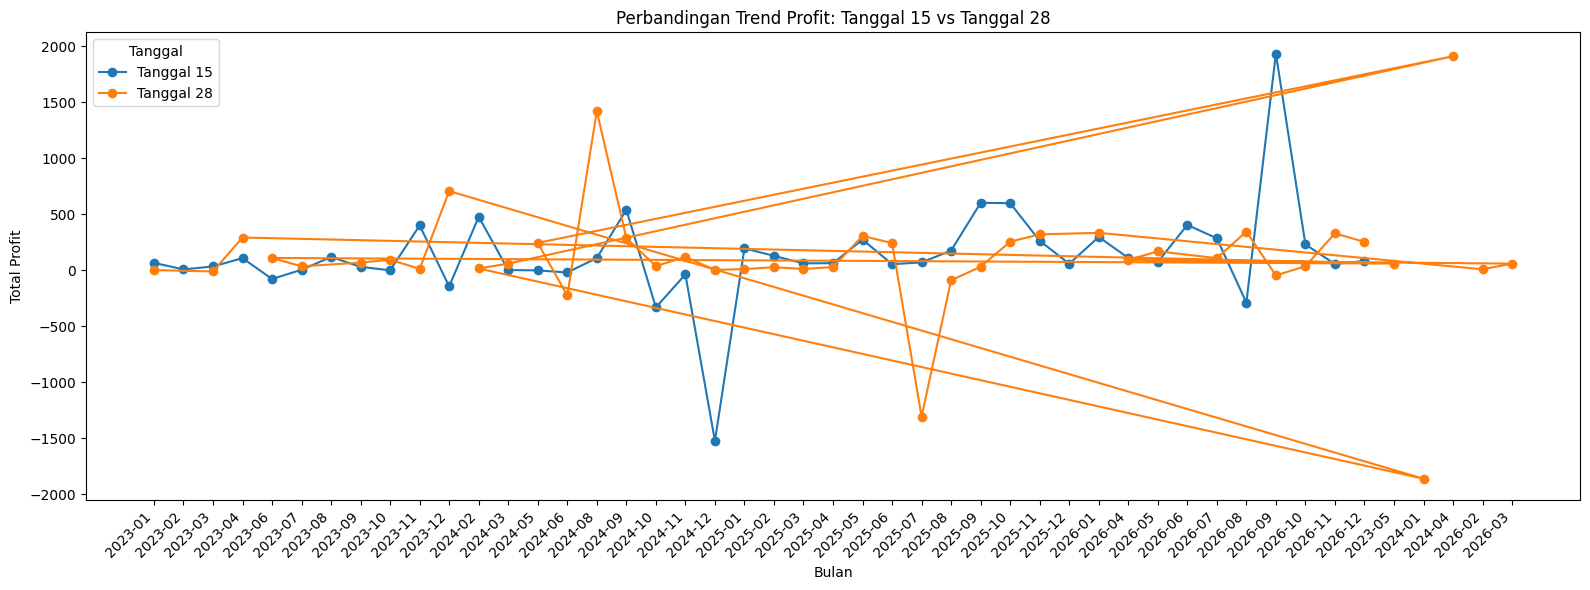

In [51]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Day'] = df['Order Date'].dt.day
df['YearMonth'] = df['Order Date'].dt.to_period('M').astype(str)

filtered = df[df['Day'].isin([15, 28])]
monthly = filtered.groupby(['YearMonth', 'Day'])['Profit'].sum().reset_index()

plt.figure(figsize=(16, 6))
for day in [15, 28]:
    data = monthly[monthly['Day'] == day]
    plt.plot(data['YearMonth'], data['Profit'], marker='o', label=f'Tanggal {day}')

plt.title('Perbandingan Trend Profit: Tanggal 15 vs Tanggal 28')
plt.xlabel('Bulan')
plt.ylabel('Total Profit')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tanggal')
plt.tight_layout()
plt.show()